In [1]:
import os, re, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import librosa
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

In [11]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Training on:", device)


Training on: mps


In [12]:
CSV_IN = "speech_dataset_updated.csv"  
df = pd.read_csv(CSV_IN)

DATA_ROOT = os.path.abspath("./data")

def fix_path(x):
    x = str(x).replace("\\", "/")
    x = x.replace("./data/", "").replace("data/", "")
    return os.path.join(DATA_ROOT, x)

df["Filepath"] = df["Filepath"].apply(fix_path)

print("Loaded:", df.shape)
df.head()


Loaded: (74705, 4)


,Dataset,Filepath,Filename,Emotion
0,CREMA-D,/Users/owner/Downloads/emotion-recog-audio/dat...,1001_DFA_ANG_XX.wav,Anger
1,CREMA-D,/Users/owner/Downloads/emotion-recog-audio/dat...,1001_DFA_DIS_XX.wav,Disgust
2,CREMA-D,/Users/owner/Downloads/emotion-recog-audio/dat...,1001_DFA_FEA_XX.wav,Fear
3,CREMA-D,/Users/owner/Downloads/emotion-recog-audio/dat...,1001_DFA_HAP_XX.wav,Happy
4,CREMA-D,/Users/owner/Downloads/emotion-recog-audio/dat...,1001_DFA_NEU_XX.wav,Neutral


In [13]:
esd_folder_map = {
    "Anger": "Angry",
    "Happy": "Happy",
    "Neutral": "Neutral",
    "Sad": "Sad",
    "Surprise": "Surprise",
}

def fix_esd_row(row):
    fname = os.path.basename(str(row["Filename"]))
    speaker = fname.split("_")[0] 
    emo = row["Emotion"]
    emo_folder = esd_folder_map.get(emo)

    if emo_folder is None:
        return row["Filepath"]

    return os.path.join(DATA_ROOT, "esd", speaker, emo_folder, fname)

mask_esd = df["Dataset"].astype(str).str.lower().eq("esd")
df.loc[mask_esd, "Filepath"] = df.loc[mask_esd].apply(fix_esd_row, axis=1)

print("ESD paths updated.")


ESD paths updated.


Training

In [14]:
target_emotions = ["Anger", "Disgust", "Fear", "Happy", "Neutral", "Sad"]

df_filtered = df[df["Emotion"].isin(target_emotions)].copy()
print("Before dropping missing:", df_filtered.shape)

exists_mask = df_filtered["Filepath"].apply(os.path.exists)
missing_count = (~exists_mask).sum()
print("Missing in filtered:", missing_count)

if missing_count > 0:
    print("Missing datasets:\n", df_filtered.loc[~exists_mask, "Dataset"].value_counts().head())

df_filtered = df_filtered[exists_mask].copy()
print("After dropping missing:", df_filtered.shape)

print("Datasets:\n", df_filtered["Dataset"].value_counts())
print("Emotions:\n", df_filtered["Emotion"].value_counts())

df_filtered.to_csv("speech_dataset_final.csv", index=False)
print("Saved -> speech_dataset_final.csv")

Before dropping missing: (51472, 4)
Missing in filtered: 1
Missing datasets:
 Dataset
MELD    1
Name: count, dtype: int64
After dropping missing: (51471, 4)
Datasets:
 Dataset
MLEND      16410
ESD        14000
MELD        8783
CREMA-D     7442
TESS        2400
RAVDESS     1056
JL           960
SAVEE        420
Name: count, dtype: int64
Emotions:
 Emotion
Neutral    18339
Happy      15629
Anger       6772
Sad         6346
Disgust     2194
Fear        2191
Name: count, dtype: int64
Saved -> speech_dataset_final.csv


In [15]:
def speaker_id_from_path(p: str) -> str:
    p = str(p).replace("\\", "/")
    pl = p.lower()
    fname = os.path.basename(p)

    if "crema" in pl:
        return f"CREMA_{fname.split('_')[0]}"

    if "ravdess" in pl:
        m = re.search(r"actor_(\d+)", pl)
        if m:
            return f"RAVDESS_{m.group(1)}"
        return "RAVDESS_UNKNOWN"

    if "savee" in pl:
        return f"SAVEE_{fname.split('_')[0]}"

    if "/esd/" in pl:
        parts = p.split("/")
        parts_l = [x.lower() for x in parts]
        i = parts_l.index("esd")
        if i + 1 < len(parts):
            return f"ESD_{parts[i+1]}"
        return "ESD_UNKNOWN"

    if "tess" in pl:
        folder = os.path.basename(os.path.dirname(p))
        if "_" in folder:
            spk = folder.split("_", 1)[0]
            return f"TESS_{spk}"
        return f"TESS_{folder}"

    if "jl" in pl:
        return f"JL_{fname.split('_')[0]}"

    return "UNK_" + fname.split("_")[0]

In [16]:
df_filtered = df_filtered.copy()
df_filtered["speaker_id"] = df_filtered["Filepath"].astype(str).apply(speaker_id_from_path)

le = LabelEncoder()
y = le.fit_transform(df_filtered["Emotion"].astype(str).values)
X = df_filtered["Filepath"].astype(str).values
groups = df_filtered["speaker_id"].astype(str).values

print("Classes:", list(le.classes_))
print("Total samples:", len(X))
print("Unique speakers:", len(np.unique(groups)))

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, temp_idx = next(gss1.split(X, y, groups=groups))

X_train, y_train, g_train = X[train_idx], y[train_idx], groups[train_idx]
X_temp,  y_temp,  g_temp  = X[temp_idx],  y[temp_idx],  groups[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
val_idx_rel, test_idx_rel = next(gss2.split(X_temp, y_temp, groups=g_temp))

X_val,  y_val,  g_val  = X_temp[val_idx_rel],  y_temp[val_idx_rel],  g_temp[val_idx_rel]
X_test, y_test, g_test = X_temp[test_idx_rel], y_temp[test_idx_rel], g_temp[test_idx_rel]

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

train_s, val_s, test_s = set(g_train), set(g_val), set(g_test)
print("\nSpeaker overlap:")
print("Train∩Val :", len(train_s & val_s))
print("Train∩Test:", len(train_s & test_s))
print("Val∩Test  :", len(val_s & test_s))

if (train_s & val_s) or (train_s & test_s) or (val_s & test_s):
    raise ValueError("Speaker leakage detected. Fix speaker_id_from_path().")

SPLIT_DIR = "splits_speaker_safe"
os.makedirs(SPLIT_DIR, exist_ok=True)

pd.DataFrame({"Filepath": X_train, "LabelID": y_train, "SpeakerID": g_train}).to_csv(os.path.join(SPLIT_DIR, "split_train.csv"), index=False)
pd.DataFrame({"Filepath": X_val,   "LabelID": y_val,   "SpeakerID": g_val}).to_csv(os.path.join(SPLIT_DIR, "split_val.csv"), index=False)
pd.DataFrame({"Filepath": X_test,  "LabelID": y_test,  "SpeakerID": g_test}).to_csv(os.path.join(SPLIT_DIR, "split_test.csv"), index=False)
pd.DataFrame({"ClassName": le.classes_}).to_csv(os.path.join(SPLIT_DIR, "classes.csv"), index=False)

joblib.dump(le, os.path.join(SPLIT_DIR, "label_encoder.joblib"))

print("\nSaved speaker-safe splits ->", SPLIT_DIR)

Classes: ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad']
Total samples: 51471
Unique speakers: 17573
Train: 42938 Val: 4720 Test: 3813

Speaker overlap:
Train∩Val : 0
Train∩Test: 0
Val∩Test  : 0

Saved speaker-safe splits -> splits_speaker_safe


In [17]:
class_counts = np.bincount(y_train)
num_classes = len(class_counts)
total = class_counts.sum()

print("Train counts per class:", dict(zip(le.classes_, class_counts)))

weights = (total / (num_classes * class_counts)) ** 0.5  

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print("Class weights:", dict(zip(le.classes_, weights)))

Train counts per class: {'Anger': np.int64(5549), 'Disgust': np.int64(1929), 'Fear': np.int64(1926), 'Happy': np.int64(13005), 'Neutral': np.int64(15385), 'Sad': np.int64(5144)}
Class weights: {'Anger': np.float64(1.1356327755595519), 'Disgust': np.float64(1.9261014882784437), 'Fear': np.float64(1.927600983630728), 'Happy': np.float64(0.7418055911427344), 'Neutral': np.float64(0.6820190891138743), 'Sad': np.float64(1.1794914597743655)}


In [18]:
def spec_augment(log_mel, time_mask_pct=0.08, freq_mask_pct=0.08, num_masks=1):
    n_mels, n_frames = log_mel.shape
    out = log_mel.copy()

    for _ in range(num_masks):
        # freq mask
        f = int(freq_mask_pct * n_mels)
        if f > 0 and n_mels - f > 0:
            f0 = np.random.randint(0, n_mels - f)
            out[f0:f0 + f, :] = 0

        # time mask
        t = int(time_mask_pct * n_frames)
        if t > 0 and n_frames - t > 0:
            t0 = np.random.randint(0, n_frames - t)
            out[:, t0:t0 + t] = 0

    return out


class LiveSpectrogramDataset(Dataset):
    def __init__(
        self,
        file_paths,
        labels,
        augment=False,
        duration=3.0,
        sr=22050,
        n_mels=128,
        frames=174,
        n_fft=1024,
        hop_length=256,
        fmin=50,
        fmax=8000,
    ):
        self.file_paths = list(file_paths)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.augment = augment

        self.duration = float(duration)
        self.sr = int(sr)
        self.n_mels = int(n_mels)
        self.frames = int(frames)

        self.n_fft = int(n_fft)
        self.hop_length = int(hop_length)
        self.fmin = float(fmin)
        self.fmax = float(fmax)

        self.target_len = int(self.sr * self.duration)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]

        try:
            y, sr = librosa.load(path, sr=self.sr, mono=True)
        except Exception:
            new_idx = np.random.randint(0, len(self.file_paths))
            return self.__getitem__(new_idx)

        if len(y) < self.target_len:
            y = np.pad(y, (0, self.target_len - len(y)), mode="constant")
        else:
            y = y[:self.target_len]

        if self.augment:
            y = y * np.random.uniform(0.8, 1.2)

            # time shift
            max_shift = int(0.10 * len(y))
            if max_shift > 0:
                shift = np.random.randint(-max_shift, max_shift + 1)
                y = np.roll(y, shift)

            # gaussian noise
            noise_amp = 0.005 * np.random.uniform() * (np.max(np.abs(y)) + 1e-9)
            y = y + noise_amp * np.random.normal(size=y.shape)

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels,
            fmin=self.fmin,
            fmax=self.fmax,
            power=2.0,
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)

        log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-6)

        # spec augment
        if self.augment:
            log_mel = spec_augment(
                log_mel,
                time_mask_pct=0.08,
                freq_mask_pct=0.08,
                num_masks=1
            )

        if log_mel.shape[1] < self.frames:
            log_mel = np.pad(log_mel, ((0, 0), (0, self.frames - log_mel.shape[1])), mode="constant")
        else:
            log_mel = log_mel[:, :self.frames]

        return torch.tensor(log_mel, dtype=torch.float32), self.labels[idx]

In [19]:
BATCH_SIZE = 32

train_loader = DataLoader(
    LiveSpectrogramDataset(X_train, y_train, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    LiveSpectrogramDataset(X_val, y_val, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    LiveSpectrogramDataset(X_test, y_test, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1342
Val batches: 148
Test batches: 120


In [20]:
class AudioEmotionCNN2D(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(0.5)

        self.fc1 = nn.Linear(128 * 16 * 21, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

model = AudioEmotionCNN2D(num_classes=len(le.classes_)).to(device)
print(model)

AudioEmotionCNN2D(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=43008, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=6, bias=True)
)


In [21]:
LR = 1e-4
EPOCHS = 30

model = AudioEmotionCNN2D(num_classes=len(le.classes_)).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(weight=class_weights)

best_acc = 0.0
best_path = "audio_cnn2.pth"

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_y.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    train_loss = running_loss / total
    train_acc  = 100.0 * correct / total

    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            running_loss += loss.item() * batch_y.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)

    val_loss = running_loss / total
    val_acc  = 100.0 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss {train_loss:.4f} Acc {train_acc:.2f}% | "
          f"Val Loss {val_loss:.4f} Acc {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_path)

print("Best Val Acc:", round(best_acc, 2), "%")
print("Saved:", best_path)

Epoch 1/30 | Train Loss 1.5001 Acc 33.86% | Val Loss 1.3665 Acc 34.07%
Epoch 2/30 | Train Loss 1.4108 Acc 35.34% | Val Loss 1.3255 Acc 38.88%
Epoch 3/30 | Train Loss 1.3696 Acc 37.30% | Val Loss 1.2472 Acc 41.93%
Epoch 4/30 | Train Loss 1.3395 Acc 37.78% | Val Loss 1.2482 Acc 41.25%
Epoch 5/30 | Train Loss 1.3199 Acc 38.60% | Val Loss 1.2110 Acc 42.69%
Epoch 6/30 | Train Loss 1.3014 Acc 39.24% | Val Loss 1.2096 Acc 42.12%
Epoch 7/30 | Train Loss 1.2936 Acc 42.45% | Val Loss 1.1878 Acc 47.58%
Epoch 8/30 | Train Loss 1.2849 Acc 43.54% | Val Loss 1.1636 Acc 47.65%
Epoch 9/30 | Train Loss 1.2767 Acc 44.03% | Val Loss 1.1948 Acc 46.21%
Epoch 10/30 | Train Loss 1.2608 Acc 45.08% | Val Loss 1.1824 Acc 46.06%
Epoch 11/30 | Train Loss 1.2505 Acc 45.20% | Val Loss 1.1848 Acc 47.03%
Epoch 12/30 | Train Loss 1.2427 Acc 45.48% | Val Loss 1.1797 Acc 46.17%
Epoch 13/30 | Train Loss 1.2425 Acc 45.56% | Val Loss 1.2768 Acc 43.69%
Epoch 14/30 | Train Loss 1.2310 Acc 46.17% | Val Loss 1.2048 Acc 45.57%
E

In [ ]:
model.load_state_dict(torch.load("audio_cnn2.pth", map_location=device))
model.eval()

all_preds, all_true = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        outputs = model(batch_x)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(batch_y.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

acc = (all_preds == all_true).mean() * 100
print(f"CNN Test Accuracy: {acc:.2f}% (speaker-safe)")

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.xticks(rotation=45, ha="right")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(all_true, all_preds, target_names=le.classes_))

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(train_losses, marker="o")
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(val_accuracies, marker="o")
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
import opensmile

SPLIT_DIR   = "splits_speaker_safe"
CNN_PTH     = "audio_cnn.pth"
CNN_LE_PATH = os.path.join(SPLIT_DIR, "label_encoder.joblib")
SVM_JOBLIB  = "svm_model_for_fusion.joblib"

W_CNN = 0.60
W_SVM = 0.40

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

le = joblib.load(CNN_LE_PATH)
cnn_classes = list(le.classes_)
print("Class order:", cnn_classes)

# CNN model definition 
class AudioEmotionCNN2D(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2, 2)
        self.drop  = nn.Dropout(0.5)
        self.fc1   = nn.Linear(128 * 16 * 21, 256)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

cnn = AudioEmotionCNN2D(num_classes=len(cnn_classes)).to(device)
cnn.load_state_dict(torch.load(CNN_PTH, map_location=device))
cnn.eval()
print("Loaded CNN:", CNN_PTH)

# CNN feature extraction
def wav_to_logmel(path, duration=3.0, sr=22050, n_mels=128, frames=174, n_fft=1024):
    y, _ = librosa.load(str(path), duration=duration, sr=sr)

    # avoid librosa warning on short signals
    if len(y) < n_fft:
        y = np.pad(y, (0, n_fft - len(y)), mode="constant")

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft)
    log_mel = librosa.power_to_db(mel, ref=np.max)

    # normalize 0..1
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-6)

    # pad/truncate time frames
    if log_mel.shape[1] < frames:
        log_mel = np.pad(log_mel, ((0, 0), (0, frames - log_mel.shape[1])), mode="constant")
    else:
        log_mel = log_mel[:, :frames]

    return log_mel.astype(np.float32)

def cnn_predict_proba(paths, batch_size=32):
    probs_all = []
    with torch.no_grad():
        for i in range(0, len(paths), batch_size):
            batch = paths[i:i+batch_size]
            feats = np.stack([wav_to_logmel(p) for p in batch], axis=0)
            x = torch.tensor(feats, dtype=torch.float32).to(device)
            logits = cnn(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probs_all.append(probs)
    return np.vstack(probs_all)

smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.ComParE_2016,
    feature_level=opensmile.FeatureLevel.Functionals,
)

def extract_opensmile_features(paths):
    rows, good_paths = [], []
    failed = 0
    for p in paths:
        try:
            feats = smile.process_file(str(p)).reset_index(drop=True)
            rows.append(feats.iloc[0])
            good_paths.append(p)
        except Exception:
            failed += 1
    if not rows:
        raise ValueError("No valid files for OpenSMILE.")
    return pd.DataFrame(rows), good_paths, failed

svm = joblib.load(SVM_JOBLIB)
print("Loaded SVM:", SVM_JOBLIB)

# SVM classes
if hasattr(svm, "classes_"):
    svm_classes = list(svm.classes_)
elif hasattr(svm, "named_steps") and "clf" in svm.named_steps and hasattr(svm.named_steps["clf"], "classes_"):
    svm_classes = list(svm.named_steps["clf"].classes_)
else:
    raise ValueError("Can't find SVM classes_ inside joblib.")

print("SVM classes:", svm_classes)

missing = [c for c in cnn_classes if c not in svm_classes]
if missing:
    raise ValueError(f"SVM missing classes that CNN has: {missing}")

svm_to_cnn_idx = [svm_classes.index(c) for c in cnn_classes]
print("Reorder idx (SVM->CNN):", svm_to_cnn_idx)

# trained feature schema
TRAINED_COLS = None
if hasattr(svm, "named_steps") and "scaler" in svm.named_steps and hasattr(svm.named_steps["scaler"], "feature_names_in_"):
    TRAINED_COLS = list(svm.named_steps["scaler"].feature_names_in_)
elif hasattr(svm, "feature_names_in_"):
    TRAINED_COLS = list(svm.feature_names_in_)

if TRAINED_COLS is None:
    raise ValueError("Cannot find feature_names_in_ in SVM pipeline. Re-save/retrain SVM with stable schema.")

print("SVM trained feature count:", len(TRAINED_COLS))

def align_opensmile_columns(X_svm: pd.DataFrame) -> pd.DataFrame:
    # schema diagnostics
    missing_cols = [c for c in TRAINED_COLS if c not in X_svm.columns]
    extra_cols   = [c for c in X_svm.columns if c not in TRAINED_COLS]

    print("\nFeature schema check:")
    print("Current extracted cols:", X_svm.shape[1])
    print("Trained cols:", len(TRAINED_COLS))
    print("Missing cols:", len(missing_cols))
    print("Extra cols:", len(extra_cols))

    if X_svm.shape[1] == len(TRAINED_COLS) and (len(missing_cols) > 0 or len(extra_cols) > 0):
        print("Column names mismatch but same width -> applying safe rename-by-position.")
        X2 = X_svm.copy()
        X2.columns = TRAINED_COLS
        return X2

    return X_svm.reindex(columns=TRAINED_COLS, fill_value=0.0)

def svm_predict_proba(paths):
    X_svm, good_paths, failed = extract_opensmile_features(paths)
    X_svm = align_opensmile_columns(X_svm)
    p = svm.predict_proba(X_svm)
    p = p[:, svm_to_cnn_idx]
    return p, good_paths, failed

def ensemble_predict(paths, w_cnn=W_CNN, w_svm=W_SVM):
    p_svm, good_paths, failed = svm_predict_proba(paths)
    p_cnn = cnn_predict_proba(good_paths)

    p_ens = (w_cnn * p_cnn) + (w_svm * p_svm)
    p_ens = p_ens / (p_ens.sum(axis=1, keepdims=True) + 1e-12)

    pred_idx = np.argmax(p_ens, axis=1)
    pred_lbl = [cnn_classes[i] for i in pred_idx]
    return good_paths, pred_lbl, p_ens, p_cnn, p_svm, failed

# Evaluate on speaker-safe split 
test_df = pd.read_csv(os.path.join(SPLIT_DIR, "split_test.csv"))
test_paths = test_df["Filepath"].astype(str).tolist()
y_true_id  = test_df["LabelID"].astype(int).to_numpy()

print("\nSpeaker-safe test total:", len(test_paths))
path_to_label = dict(zip(test_paths, y_true_id))

# CNN-only
p_cnn = cnn_predict_proba(test_paths, batch_size=32)
y_pred_cnn = np.argmax(p_cnn, axis=1)
cnn_acc = accuracy_score(y_true_id, y_pred_cnn) * 100
print(f"\nCNN-only Test Accuracy: {cnn_acc:.2f}%")
print(classification_report(y_true_id, y_pred_cnn, target_names=cnn_classes, zero_division=0))

# SVM-only
p_svm, good_paths, failed = svm_predict_proba(test_paths)
y_true_good = np.array([path_to_label[p] for p in good_paths], dtype=int)
y_pred_svm = np.argmax(p_svm, axis=1)
svm_acc = accuracy_score(y_true_good, y_pred_svm) * 100
print(f"\nSVM-only Test Accuracy: {svm_acc:.2f}% ({len(y_true_good)} evaluated)")
print(f"OpenSMILE failed files: {failed}")
print(classification_report(y_true_good, y_pred_svm, target_names=cnn_classes, zero_division=0))

# Ensemble
good_paths_e, pred_lbls_e, p_ens, _, _, failed_e = ensemble_predict(test_paths)
y_true_good_e = np.array([path_to_label[p] for p in good_paths_e], dtype=int)
y_pred_ens = np.array([cnn_classes.index(lbl) for lbl in pred_lbls_e], dtype=int)

ens_acc = accuracy_score(y_true_good_e, y_pred_ens) * 100
print(f"\nEnsemble Test Accuracy: {ens_acc:.2f}% ({len(y_true_good_e)} evaluated)")
print(f"OpenSMILE failed files (ensemble): {failed_e}")
print(classification_report(y_true_good_e, y_pred_ens, target_names=cnn_classes, zero_division=0))

Device: mps
Class order: ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad']
Loaded CNN: audio_cnn.pth
Loaded SVM: svm_model_for_fusion.joblib
SVM classes: ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad']
Reorder idx (SVM->CNN): [0, 1, 2, 3, 4, 5]
SVM trained feature count: 6373

Speaker-safe test total: 3813

CNN-only Test Accuracy: 52.77%
              precision    recall  f1-score   support

       Anger       0.45      0.76      0.56       525
     Disgust       0.32      0.38      0.35        66
        Fear       0.48      0.23      0.31        71
       Happy       0.52      0.48      0.50      1225
     Neutral       0.53      0.51      0.52      1415
         Sad       0.88      0.52      0.65       511

    accuracy                           0.53      3813
   macro avg       0.53      0.48      0.48      3813
weighted avg       0.55      0.53      0.53      3813


Feature schema check:
Current extracted cols: 6373
Trained cols: 6373
Missing cols: 5443
Extra cols: 5

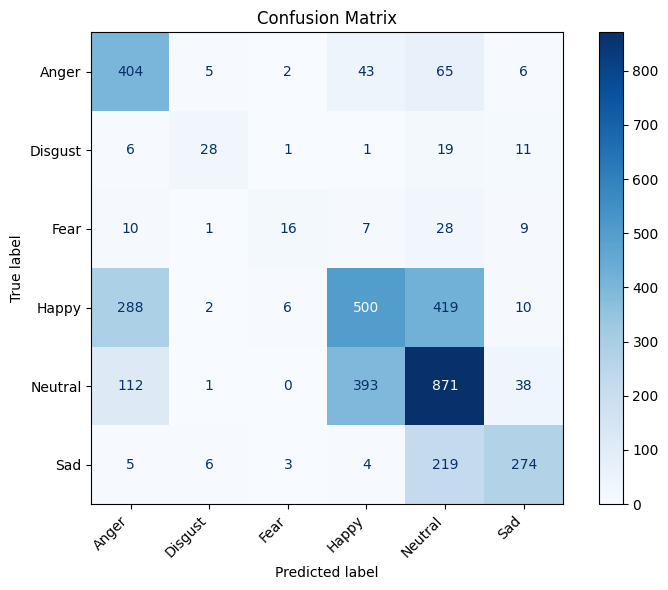

In [29]:
cm = confusion_matrix(y_true_good_e, y_pred_ens)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cnn_classes)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.xticks(rotation=45, ha="right")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()